# Advanced AI Agent Development with LangChain and LangGraph

Welcome to this advanced tutorial on building sophisticated AI agents! In this notebook, we'll create a more complex Recipe Assistant agent with structured outputs, advanced memory management, and contextual understanding.

## What We'll Build

We'll create an advanced agent that can:
- Process user inputs with full contextual understanding
- Generate structured outputs for consistent responses
- Maintain sophisticated memory of conversation history
- Use multiple specialized nodes for different reasoning tasks
- Self-correct when it makes mistakes

This agent will operate in the culinary domain, helping users discover recipes, plan meals, and learn cooking techniques.

## Prerequisites

- Intermediate Python knowledge
- Basic understanding of LangChain and LangGraph
- An OpenAI API key

Let's get started!

## 1. Setting Up Our Environment

In [1]:
!pip install langchain langchain-openai langgraph pydantic typing-extensions

In [20]:
import os
from typing import Dict, List, Any, Optional, Tuple, TypedDict, Annotated, Union, Literal
from typing_extensions import TypeAlias
import json
from datetime import datetime
import re

# LangChain imports
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder, PromptTemplate
from langchain.schema import SystemMessage, HumanMessage, AIMessage
from langchain.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, FunctionMessage
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.pydantic_v1 import BaseModel, Field

# LangGraph imports
import langgraph as lg
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "xx"

## 2. Defining Structured Outputs

One key improvement in our advanced agent is the use of structured outputs. This ensures consistency and makes it easier to process the agent's responses programmatically.

In [4]:
# Define structured output schemas using Pydantic
class RecipeInfo(BaseModel):
    """Information about a recipe"""
    name: str = Field(description="The name of the recipe")
    cuisine: str = Field(description="The cuisine type (e.g., Italian, Mexican, etc.)")
    difficulty: str = Field(description="Difficulty level (Easy, Medium, Hard)")
    prep_time_minutes: int = Field(description="Preparation time in minutes")
    cook_time_minutes: int = Field(description="Cooking time in minutes")
    ingredients: List[str] = Field(description="List of ingredients with quantities")
    instructions: List[str] = Field(description="Step-by-step cooking instructions")
    dietary_info: List[str] = Field(description="Dietary information (e.g., vegetarian, gluten-free)")

class NutritionInfo(BaseModel):
    """Nutrition information for a food item"""
    food_name: str = Field(description="Name of the food item")
    calories_per_serving: int = Field(description="Calories per typical serving")
    protein_grams: float = Field(description="Protein content in grams")
    carbs_grams: float = Field(description="Carbohydrate content in grams")
    fat_grams: float = Field(description="Fat content in grams")
    fiber_grams: float = Field(description="Fiber content in grams")
    key_vitamins: List[str] = Field(description="Key vitamins and minerals")
    serving_size: str = Field(description="Typical serving size")

class UserPreference(BaseModel):
    """User's food preferences and restrictions"""
    dietary_restrictions: List[str] = Field(description="Dietary restrictions (e.g., vegetarian, vegan)")
    allergies: List[str] = Field(description="Food allergies")
    disliked_ingredients: List[str] = Field(description="Ingredients the user dislikes")
    favorite_cuisines: List[str] = Field(description="User's favorite cuisine types")
    cooking_skill: str = Field(description="User's cooking skill level (Beginner, Intermediate, Advanced)")

class AgentAction(BaseModel):
    """Action the agent decides to take"""
    action_type: str = Field(description="Type of action to take (use_tool, respond, clarify, etc.)")
    tool_name: Optional[str] = Field(None, description="Name of the tool to use if action_type is use_tool")
    tool_input: Optional[Any] = Field(None, description="Input for the tool if action_type is use_tool")
    response: Optional[str] = Field(None, description="Direct response if action_type is respond")
    reasoning: str = Field(description="Agent's reasoning for taking this action")

## 3. Advanced Memory Management

Let's create a sophisticated memory system that not only stores conversation history but also extracts and maintains user preferences over time.

In [5]:
# Define our agent's state with advanced memory
class AgentState(TypedDict):
    # Conversation history
    messages: List[Dict[str, Any]]
    # Current user input
    user_input: str
    # Extracted user preferences
    user_preferences: Dict[str, Any]
    # Agent's current action
    agent_action: Optional[Dict[str, Any]]
    # Tool response if a tool was used
    tool_response: Optional[Any]
    # Structured data from the conversation
    structured_data: Dict[str, Any]
    # Agent's internal thoughts (not shown to user)
    agent_scratchpad: List[str]
    # Final response to user
    final_response: Optional[str]

In [6]:
# Function to extract conversation context from recent messages
def extract_conversation_context(messages: List[Dict[str, Any]], window_size: int = 5) -> str:
    """Extract the most recent conversation context within a sliding window"""
    recent_messages = messages[-window_size:] if len(messages) > window_size else messages

    context = ""
    for msg in recent_messages:
        role = msg["role"]
        content = msg["content"]
        context += f"{role.capitalize()}: {content}\n\n"

    return context.strip()

In [7]:
# Function to update user preferences based on conversation
def update_user_preferences(state: AgentState) -> Dict[str, Any]:
    """Extract and update user preferences from conversation"""
    # Get existing preferences
    preferences = state.get("user_preferences", {})

    # Get recent conversation context
    recent_context = extract_conversation_context(state["messages"], window_size=10)
    user_input = state["user_input"]

    # Use LLM to extract preferences
    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

    prompt = f"""
    Based on the conversation history and current user input, extract or update the user's food preferences.

    Current known preferences: {json.dumps(preferences, indent=2)}

    Recent conversation:
    {recent_context}

    Current user input: {user_input}

    Extract any new or updated preferences related to:
    - Dietary restrictions (vegetarian, vegan, etc.)
    - Allergies
    - Disliked ingredients
    - Favorite cuisines
    - Cooking skill level

    Return ONLY a JSON object with the updated preferences. If no new preferences are found, return the existing preferences.
    """

    try:
        response = llm.invoke(prompt)
        # Extract JSON from response
        json_match = re.search(r'\{[\s\S]*\}', response.content)
        if json_match:
            new_preferences = json.loads(json_match.group(0))
            # Merge with existing preferences
            preferences.update(new_preferences)
    except Exception as e:
        print(f"Error updating preferences: {e}")

    return preferences

## 4. Enhanced Tools with Structured Outputs

In [8]:
# Initialize our language model
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)
# For structured outputs, we'll use a more deterministic model
structured_llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2)

In [9]:
@tool
def search_recipes(query: str) -> List[Dict[str, Any]]:
    """Search for recipes based on ingredients, cuisine type, or dish name.
    Returns a list of recipe summaries."""

    # In a real application, this would query a recipe database
    prompt = ChatPromptTemplate.from_template(
        """Generate 3 recipe summaries matching this search: {query}.
        For each recipe, include name, cuisine type, difficulty, prep time, and a brief description.
        Format the output as a JSON list of objects with keys: name, cuisine, difficulty, prep_time_minutes, description.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"query": query})

    return result

@tool
def get_detailed_recipe(recipe_name: str) -> Dict[str, Any]:
    """Get detailed information about a specific recipe including ingredients and instructions."""

    prompt = ChatPromptTemplate.from_template(
        """Generate a detailed recipe for {recipe_name}.
        Include all ingredients with measurements, step-by-step instructions, cooking time, difficulty level, and dietary information.
        Format as a JSON object matching the RecipeInfo schema with these fields:
        name, cuisine, difficulty, prep_time_minutes, cook_time_minutes, ingredients (list), instructions (list), dietary_info (list).
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"recipe_name": recipe_name})

    return result

@tool
def get_nutrition_info(food_item: str) -> Dict[str, Any]:
    """Get detailed nutrition information for a food item or ingredient."""

    prompt = ChatPromptTemplate.from_template(
        """Provide detailed nutrition information for {food_item}.
        Include calories, protein, carbs, fat, fiber, key vitamins/minerals, and typical serving size.
        Format as a JSON object matching the NutritionInfo schema with these fields:
        food_name, calories_per_serving, protein_grams, carbs_grams, fat_grams, fiber_grams, key_vitamins (list), serving_size.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"food_item": food_item})

    return result

@tool
def generate_meal_plan(requirements: str) -> Dict[str, List[Dict[str, Any]]]:
    """Generate a meal plan based on dietary requirements, preferences, and number of days."""

    prompt = ChatPromptTemplate.from_template(
        """Create a meal plan based on these requirements: {requirements}.
        Include breakfast, lunch, dinner, and snacks for each day.
        Format as a JSON object with days as keys and meals as values.
        Each meal should include name, brief description, and main ingredients.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"requirements": requirements})

    return result

@tool
def explain_cooking_technique(technique: str) -> Dict[str, Any]:
    """Explain a cooking technique with steps, tips, and example recipes."""

    prompt = ChatPromptTemplate.from_template(
        """Explain the cooking technique: {technique}.
        Include a definition, step-by-step instructions, common mistakes to avoid, and 2-3 example dishes that use this technique.
        Format as a JSON object with keys: technique_name, definition, steps (list), common_mistakes (list), example_dishes (list).
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    result = chain.invoke({"technique": technique})

    return result

## 5. Advanced Agent Nodes

Now we'll create specialized nodes for our agent graph that handle different aspects of the agent's reasoning process.

In [10]:
# Node 1: Context Analysis - Analyzes user input in context of conversation history
def context_analysis_node(state: AgentState) -> AgentState:
    """Analyze user input in the context of conversation history"""
    # Get recent conversation context
    recent_context = extract_conversation_context(state["messages"], window_size=5)
    user_input = state["user_input"]

    # Use LLM to analyze the context
    prompt = ChatPromptTemplate.from_template(
        """Analyze the user's input in the context of the recent conversation.

        Recent conversation:
        {recent_context}

        Current user input: {user_input}

        Provide a brief analysis of:
        1. What is the user's primary intent?
        2. Is this a follow-up to a previous topic? If so, what topic?
        3. Are there any implicit references to previous parts of the conversation?
        4. What key information should be extracted from this input?

        Format your response as a JSON object with keys: primary_intent, is_followup, previous_topic, implicit_references, key_information.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    analysis = chain.invoke({"recent_context": recent_context, "user_input": user_input})

    # Update the agent's scratchpad with this analysis
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Context Analysis: {json.dumps(analysis, indent=2)}"]

    # Update structured data
    state["structured_data"] = state.get("structured_data", {})
    state["structured_data"]["context_analysis"] = analysis

    # Update user preferences based on the conversation
    state["user_preferences"] = update_user_preferences(state)

    return state

In [11]:
# Node 2: Action Planning - Decides what action to take
def action_planning_node(state: AgentState) -> AgentState:
    """Decide what action to take based on context analysis"""
    # Get context analysis
    context_analysis = state["structured_data"].get("context_analysis", {})
    user_preferences = state["user_preferences"]
    user_input = state["user_input"]

    # List available tools
    tools_description = """
    Available tools:
    1. search_recipes(query): Search for recipes based on ingredients, cuisine type, or dish name
    2. get_detailed_recipe(recipe_name): Get detailed information about a specific recipe
    3. get_nutrition_info(food_item): Get nutrition information for a food item
    4. generate_meal_plan(requirements): Generate a meal plan based on requirements
    5. explain_cooking_technique(technique): Explain a cooking technique
    """

    # Use LLM to decide on an action
    prompt = ChatPromptTemplate.from_template(
        """Based on the user input and conversation context, decide what action to take.

        User input: {user_input}

        Context analysis: {context_analysis}

        User preferences: {user_preferences}

        {tools_description}

        Decide on ONE of these actions:
        1. use_tool: Use one of the available tools
        2. respond: Respond directly to the user without using a tool
        3. clarify: Ask for clarification if the user's request is ambiguous

        If choosing use_tool, specify which tool and what input to provide.

        Format your response as a JSON object matching the AgentAction schema with these fields:
        action_type, tool_name (if applicable), tool_input (if applicable), response (if applicable), reasoning
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    action = chain.invoke({
        "user_input": user_input,
        "context_analysis": json.dumps(context_analysis, indent=2),
        "user_preferences": json.dumps(user_preferences, indent=2),
        "tools_description": tools_description
    })

    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Action Planning: {json.dumps(action, indent=2)}"]

    # Store the action
    state["agent_action"] = action

    return state

In [12]:
# Node 3: Tool Execution - Executes the chosen tool if applicable
def tool_execution_node(state: AgentState) -> AgentState:
    """Execute the tool specified in the agent action"""
    action = state["agent_action"]

    # If the action is not to use a tool, skip
    if action["action_type"] != "use_tool" or not action.get("tool_name"):
        return state

    tool_name = action["tool_name"]
    tool_input = action["tool_input"]

    try:
        # Execute the appropriate tool
        if tool_name == "search_recipes":
            result = search_recipes(tool_input)
        elif tool_name == "get_detailed_recipe":
            result = get_detailed_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            result = get_nutrition_info(tool_input)
        elif tool_name == "generate_meal_plan":
            result = generate_meal_plan(tool_input)
        elif tool_name == "explain_cooking_technique":
            result = explain_cooking_technique(tool_input)
        else:
            result = {"error": f"Unknown tool: {tool_name}"}
    except Exception as e:
        result = {"error": f"Error executing {tool_name}: {str(e)}"}

    # Store the tool response
    state["tool_response"] = result

    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Tool Execution ({tool_name}): {json.dumps(result, indent=2)}"]

    return state

In [13]:
# Node 4: Response Generation - Creates the final response to the user
def response_generation_node(state: AgentState) -> AgentState:
    """Generate the final response to the user"""
    action = state["agent_action"]
    user_preferences = state["user_preferences"]

    # If the action is a direct response, use that
    if action["action_type"] == "respond" and action.get("response"):
        response = action["response"]
    # If the action is to clarify, use the clarification question
    elif action["action_type"] == "clarify" and action.get("response"):
        response = action["response"]
    # If a tool was used, format the tool response
    elif action["action_type"] == "use_tool" and state.get("tool_response"):
        tool_name = action["tool_name"]
        tool_result = state["tool_response"]

        # Use LLM to format the tool result into a natural response
        prompt = ChatPromptTemplate.from_template(
            """Format the following tool result into a natural, conversational response.

            Tool used: {tool_name}
            Tool result: {tool_result}
            User preferences: {user_preferences}

            Create a helpful, friendly response that presents the information clearly.
            If the tool result contains errors, acknowledge them and offer alternatives.
            Tailor your response to match the user's preferences when relevant.

            Response:
            """
        )

        chain = prompt | llm | StrOutputParser()
        response = chain.invoke({
            "tool_name": tool_name,
            "tool_result": json.dumps(tool_result, indent=2),
            "user_preferences": json.dumps(user_preferences, indent=2)
        })
    else:
        # Fallback response if something went wrong
        response = "I'm not sure how to respond to that. Could you rephrase your question?"

    # Store the final response
    state["final_response"] = response

    # Update the conversation history
    state["messages"].append({"role": "human", "content": state["user_input"]})
    state["messages"].append({"role": "ai", "content": response})

    return state

In [14]:
# Node 5: Self-Reflection - Analyzes the agent's performance and learns from it
def self_reflection_node(state: AgentState) -> AgentState:
    """Reflect on the agent's performance and update internal knowledge"""
    # This would be more sophisticated in a production system
    # For now, we'll just log some information

    action = state["agent_action"]
    final_response = state["final_response"]

    # Use LLM to reflect on the interaction
    prompt = ChatPromptTemplate.from_template(
        """Reflect on this interaction:

        User input: {user_input}
        Action taken: {action}
        Final response: {final_response}

        Provide a brief reflection on:
        1. Was this the optimal action for the user's request?
        2. Could the response be improved? How?
        3. What should be remembered for future interactions with this user?

        Format your response as a JSON object with keys: optimal_action, improvement_suggestions, future_considerations.
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    reflection = chain.invoke({
        "user_input": state["user_input"],
        "action": json.dumps(action, indent=2),
        "final_response": final_response
    })

    # Update the agent's scratchpad
    state["agent_scratchpad"] = state.get("agent_scratchpad", []) + [f"Self-Reflection: {json.dumps(reflection, indent=2)}"]

    # Store the reflection in structured data
    state["structured_data"] = state.get("structured_data", {})
    state["structured_data"]["reflection"] = reflection

    return state

## 6. Building the Advanced Agent Graph

Now we'll connect our specialized nodes into a sophisticated agent workflow using LangGraph.

In [15]:
# Create the workflow graph
workflow = StateGraph(AgentState)

# Add our nodes to the graph
workflow.add_node("context_analysis", context_analysis_node)
workflow.add_node("action_planning", action_planning_node)
workflow.add_node("tool_execution", tool_execution_node)
workflow.add_node("response_generation", response_generation_node)
workflow.add_node("self_reflection", self_reflection_node)

# Define the flow between nodes
workflow.set_entry_point("context_analysis")
workflow.add_edge("context_analysis", "action_planning")
workflow.add_edge("action_planning", "tool_execution")
workflow.add_edge("tool_execution", "response_generation")
workflow.add_edge("response_generation", "self_reflection")
workflow.add_edge("self_reflection", END)

# Compile the graph into a runnable agent
advanced_recipe_agent = workflow.compile()

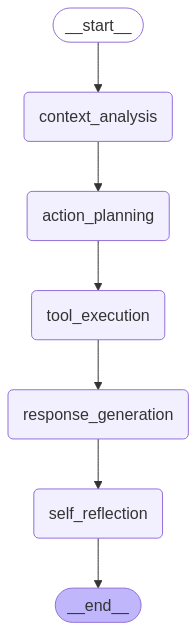

In [16]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        advanced_recipe_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## 7. Creating an Enhanced Chat Interface

In [17]:
class ChatSession:
    """A class to manage chat sessions with our advanced agent"""

    def __init__(self):
        """Initialize a new chat session"""
        self.messages = []
        self.user_preferences = {}
        self.structured_data = {}

    def chat(self, user_input: str, debug: bool = False) -> str:
        """Process a user message and get the agent's response"""
        # Initialize the agent state
        state = {
            "messages": self.messages,
            "user_input": user_input,
            "user_preferences": self.user_preferences,
            "agent_action": None,
            "tool_response": None,
            "structured_data": self.structured_data,
            "agent_scratchpad": [],
            "final_response": None
        }

        # Run the agent
        result = advanced_recipe_agent.invoke(state)

        # Update session state
        self.messages = result["messages"]
        self.user_preferences = result["user_preferences"]
        self.structured_data = result["structured_data"]

        # Print debug information if requested
        if debug:
            print("\n=== DEBUG INFORMATION ===")
            print("\nAgent Scratchpad:")
            for note in result["agent_scratchpad"]:
                print(f"\n{note}")
            print("\nUser Preferences:")
            print(json.dumps(self.user_preferences, indent=2))
            print("\n=== END DEBUG INFORMATION ===\n")

        return result["final_response"]

    def get_conversation_history(self) -> List[Dict[str, str]]:
        """Get the conversation history"""
        return self.messages

    def get_user_preferences(self) -> Dict[str, Any]:
        """Get the user preferences"""
        return self.user_preferences

In [18]:
def interactive_chat(debug: bool = False):
    """Interactive chat with our advanced recipe agent"""
    session = ChatSession()

    print("Welcome to Chef GPT Advanced! Type 'exit' to end the conversation or 'debug' to toggle debug mode.")
    print("What cooking questions can I help you with today?")

    while True:
        user_input = input("\nYou: ")

        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            break
        elif user_input.lower() == 'debug':
            debug = not debug
            print(f"\nDebug mode {'enabled' if debug else 'disabled'}")
            continue

        response = session.chat(user_input, debug)
        print(f"\nChef GPT: {response}")

# Uncomment to start an interactive chat
# interactive_chat()

In [18]:
interactive_chat()

Welcome to Chef GPT Advanced! Type 'exit' to end the conversation or 'debug' to toggle debug mode.
What cooking questions can I help you with today?

You: hi!

Chef GPT: Hello! How can I assist you today?

You: exit

Chef GPT: Goodbye! Happy cooking!


## 8. Testing Our Advanced Agent

Let's test our agent with a series of interactions to demonstrate its capabilities:

In [19]:
# Create a test session
test_session = ChatSession()

# Test 1: Initial greeting and preference gathering
response = test_session.chat("Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.")
print("Test 1 - Initial greeting with preferences")
print(f"User: Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

<ipython-input-11-d2c1dcc4e0a0>:16: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = search_recipes(tool_input)


Test 1 - Initial greeting with preferences
User: Hi! I'm looking for some healthy dinner ideas. I'm vegetarian and trying to eat more protein.
Agent: Based on your preferences, here are some vegetarian recipes that are sure to satisfy your protein needs and cooking skill level:

1. Quinoa Stuffed Bell Peppers (American cuisine, Medium difficulty, 45 minutes prep time): These bell peppers are filled with a mixture of quinoa, black beans, corn, and spices, making them a delicious and protein-packed vegetarian dinner option.

2. Chickpea and Spinach Curry (Indian cuisine, Easy difficulty, 30 minutes prep time): This flavorful curry is made with chickpeas, spinach, tomatoes, and a blend of Indian spices. It's a quick and easy vegetarian dinner that is high in protein.

3. Lentil Shepherd's Pie (British cuisine, Medium difficulty, 60 minutes prep time): This vegetarian twist on a classic shepherd's pie is made with lentils, vegetables, and a creamy mashed potato topping. It's a hearty and p

In [20]:
# Test 2: Follow-up question with context
response = test_session.chat("Can you give me a specific recipe for one of those options?")
print("Test 2 - Follow-up with context")
print(f"User: Can you give me a specific recipe for one of those options?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 2 - Follow-up with context
User: Can you give me a specific recipe for one of those options?
Agent: Based on your dietary restrictions of being vegetarian and your preference for trying to eat more protein, here are some recipe suggestions for you:

1. Quinoa Stuffed Bell Peppers (American cuisine, Medium difficulty, 45 minutes prep time): These colorful bell peppers are filled with a mixture of quinoa, black beans, corn, and spices, making it a delicious and protein-packed vegetarian dinner option.

2. Chickpea and Spinach Curry (Indian cuisine, Easy difficulty, 30 minutes prep time): This flavorful curry is made with chickpeas, spinach, tomatoes, and a blend of aromatic spices. It's a quick and easy high-protein dinner that's perfect for vegetarians.

3. Lentil Shepherd's Pie (British cuisine, Medium difficulty, 60 minutes prep time): This vegetarian twist on a classic shepherd's pie features a hearty lentil and vegetable filling topped with creamy mashed potatoes. It's a comfor

In [21]:
# Test 3: Nutrition information request
response = test_session.chat("What's the nutritional value of tofu?")
print("Test 3 - Nutrition information")
print(f"User: What's the nutritional value of tofu?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 3 - Nutrition information
User: What's the nutritional value of tofu?
Agent: I'm not sure how to respond to that. Could you rephrase your question?

--------------------------------------------------



In [22]:
# Test 4: Creative recipe request
response = test_session.chat("I want to impress my friends this weekend. Can you create a unique fusion recipe that combines Mexican and Thai cuisines but still fits my vegetarian diet?")
print("Test 4 - Creative recipe with preferences")
print(f"User: I want to impress my friends this weekend. Can you create a unique fusion recipe that combines Mexican and Thai cuisines but still fits my vegetarian diet?")
print(f"Agent: {response}")
print("\n" + "-"*50 + "\n")

Test 4 - Creative recipe with preferences
User: I want to impress my friends this weekend. Can you create a unique fusion recipe that combines Mexican and Thai cuisines but still fits my vegetarian diet?
Agent: Based on your preferences, here are some Mexican Thai fusion recipes that you might enjoy:

1. Thai Tofu Tacos:
- Cuisine: Mexican Thai fusion
- Difficulty: Medium
- Prep Time: 45 minutes
- Description: Crispy tofu marinated in Thai spices, served in tortillas with peanut sauce and cilantro.

2. Spicy Thai Corn Salad:
- Cuisine: Mexican Thai fusion
- Difficulty: Easy
- Prep Time: 20 minutes
- Description: Grilled corn with Thai chili, lime, and cilantro for a zesty kick.

3. Coconut Curry Enchiladas:
- Cuisine: Mexican Thai fusion
- Difficulty: Hard
- Prep Time: 60 minutes
- Description: Enchiladas filled with coconut curry sauce, veggies, and tofu.

These recipes align with your vegetarian diet and love for Mexican and Thai cuisines. The cooking skill level for each recipe is a

In [26]:
# Let's examine what the agent has learned about the user
print("User Preferences Learned:")
print(json.dumps(test_session.get_user_preferences(), indent=2))

User Preferences Learned:
{
  "Dietary restrictions": [
    "vegetarian"
  ],
  "Favorite cuisines": [
    "Mexican",
    "Thai"
  ],
  "Cooking skill level": "Intermediate",
  "Protein preference": "Trying to eat more protein"
}


## 9. Advanced Exercises for Students

Now it's your turn to enhance this advanced agent! Here are some challenging exercises:

### Exercise 1: Implement Branching Logic

Modify the agent graph to include conditional branching based on the action type. For example, if the action is "clarify", route to a special clarification node before generating a response.

In [ ]:
# Your code here
# Hint: Use the conditional_edge feature of LangGraph

def route_action(state: AgentState) -> str:
    """Route to different nodes based on action type"""
    action_type = state["agent_action"]["action_type"]
    if action_type == "use_tool":
        return "tool_execution"
    elif action_type == "clarify":
        return "clarification"
    else:  # respond
        return "response_generation"

# Define a clarification node
def clarification_node(state: AgentState) -> AgentState:
    """Handle clarification requests"""
    # Your implementation here
    return state

# Then update your graph with conditional edges

### Exercise 2: Add Long-Term Memory

Implement a persistent storage mechanism to remember user preferences and conversation highlights across sessions.

In [ ]:
# Your code here
# Hint: You could use a simple JSON file or a database

import json
import os

class PersistentMemory:
    """A class to manage persistent memory across sessions"""

    def __init__(self, user_id: str, storage_dir: str = "./memory"):
        self.user_id = user_id
        self.storage_dir = storage_dir
        self.file_path = f"{storage_dir}/{user_id}.json"

        # Create storage directory if it doesn't exist
        os.makedirs(storage_dir, exist_ok=True)

        # Initialize or load memory
        self.memory = self._load_memory()

    def _load_memory(self) -> Dict[str, Any]:
        """Load memory from storage"""
        if os.path.exists(self.file_path):
            with open(self.file_path, 'r') as f:
                return json.load(f)
        else:
            return {
                "user_preferences": {},
                "conversation_highlights": [],
                "last_session": None
            }

    def save_memory(self):
        """Save memory to storage"""
        with open(self.file_path, 'w') as f:
            json.dump(self.memory, f, indent=2)

    def update_preferences(self, new_preferences: Dict[str, Any]):
        """Update user preferences"""
        self.memory["user_preferences"].update(new_preferences)
        self.save_memory()

    def add_conversation_highlight(self, highlight: str):
        """Add an important conversation highlight"""
        self.memory["conversation_highlights"].append({
            "timestamp": datetime.now().isoformat(),
            "content": highlight
        })
        self.save_memory()

    def get_preferences(self) -> Dict[str, Any]:
        """Get user preferences"""
        return self.memory["user_preferences"]

    def get_conversation_highlights(self) -> List[Dict[str, str]]:
        """Get conversation highlights"""
        return self.memory["conversation_highlights"]

### Exercise 3: Implement Self-Correction

Add a mechanism for the agent to detect when it has made an error and correct itself before providing the final response.

In [ ]:
# Your code here
# Hint: Add a verification node before the final response

def verification_node(state: AgentState) -> AgentState:
    """Verify the response for accuracy and correctness"""
    response = state.get("final_response", "")
    user_input = state["user_input"]
    action = state["agent_action"]
    tool_response = state.get("tool_response")

    # Use LLM to verify the response
    prompt = ChatPromptTemplate.from_template(
        """Verify this response for accuracy and correctness:

        User input: {user_input}
        Agent action: {action}
        Tool response (if any): {tool_response}
        Final response: {response}

        Check for:
        1. Factual errors or inconsistencies
        2. Misunderstandings of the user's request
        3. Missing important information
        4. Logical contradictions

        If you find any issues, provide a corrected response. Otherwise, confirm the original response is good.

        Format your answer as a JSON with keys: has_errors (boolean), errors (list), corrected_response (string or null)
        """
    )

    chain = prompt | structured_llm | JsonOutputParser()
    verification = chain.invoke({
        "user_input": user_input,
        "action": json.dumps(action, indent=2) if action else "None",
        "tool_response": json.dumps(tool_response, indent=2) if tool_response else "None",
        "response": response
    })

    # If errors were found, update the response
    if verification.get("has_errors", False) and verification.get("corrected_response"):
        state["final_response"] = verification["corrected_response"]
        # Update the conversation history with the corrected response
        if state["messages"] and state["messages"][-1]["role"] == "ai":
            state["messages"][-1]["content"] = verification["corrected_response"]

    return state

## 10. Conclusion

Congratulations! You've built an advanced AI agent with:

1. **Structured outputs** for consistent, parseable responses
2. **Advanced memory management** that tracks user preferences
3. **Contextual understanding** using a sliding window of conversation history
4. **Specialized reasoning nodes** for different aspects of agent behavior
5. **Self-reflection** capabilities to improve over time

### Key Concepts Learned

- How to design a multi-node agent architecture with LangGraph
- How to implement structured outputs with Pydantic models
- How to maintain and use conversation context effectively
- How to extract and apply user preferences
- How to implement self-reflection and improvement mechanisms

### Next Steps

To further enhance your agent, consider:

1. Implementing retrieval-augmented generation (RAG) for accessing external knowledge
2. Adding multi-modal capabilities (processing images of food, etc.)
3. Implementing a feedback loop to learn from user interactions
4. Deploying your agent as a web service or chat application

Happy building!